### heart AVN data

In [1]:
library(parallel)
library(GenomicFeatures)
set.seed(1234)
library(repr)
library(motifmatchr)
library(fastmatch)
library(qlcMatrix)

library(ensembldb)
library(EnsDb.Hsapiens.v86)
library(AnnotationFilter)

library(Signac)
library(Seurat)
library(JASPAR2024)
library(TFBSTools)
library(BSgenome.Hsapiens.UCSC.hg38)
library(patchwork)
library(ggplot2)
library(Matrix)
library(zoo)
library(tidyr)

source("../multiome_methods/function_calls.r")
source("../multiome_methods/peak_gene_relations.r")
source("../multiome_methods/binding_site_identification.r")
source("../multiome_methods/TF_activity.r")
source("../multiome_methods/signac_utils.r")

library(dplyr)

library(ggplot2)
library(hexbin)
library(RColorBrewer)
library(cowplot)
library(gridExtra)
library(ggExtra)

library(pheatmap)
library(purrr)
library(data.table)
library(Rsamtools)
library(stringi)


Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min


Loading required package: S4Vectors

Loading required package: stats4


Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

In [2]:
dissociated_obj <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1775635064043_mopitas/plasmidpoop/dissociated_obj_footprints.rds")

In [3]:
dissociated_obj

An object of class Seurat 
612284 features across 8358 samples within 5 assays 
Active assay: RNA (32724 features, 2000 variable features)
 3 layers present: counts, data, scale.data
 4 other assays present: SCT, ATAC, peaks, chromvar
 5 dimensional reductions calculated: pca_sct, pca_rna, lsi, umap_RNA_peaks, umap_SCT_peaks

In [5]:
DefaultAssay(dissociated_obj) <- "peaks"

In [10]:
str(dissociated_obj[["peaks"]], max.level = 2)

Formal class 'ChromatinAssay' [package "Signac"] with 16 slots
  ..@ ranges            :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ motifs            :Formal class 'Motif' [package "Signac"] with 5 slots
  ..@ fragments         :List of 1
  ..@ seqinfo           : NULL
  ..@ annotation        :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ bias              : Named num [1:4096] 0.00225 0.00245 0.00606 0.00211 0.00467 ...
  .. ..- attr(*, "names")= chr [1:4096] "AAAAAA" "AAAAAC" "AAAAAG" "AAAAAT" ...
  ..@ positionEnrichment:List of 7
  ..@ links             :Formal class 'GRanges' [package "GenomicRanges"] with 7 slots
  ..@ counts            :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ data              :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  ..@ scale.data        : num[0 , 0 ] 
  ..@ assay.orig        : NULL
  ..@ var.features      : chr [1:126741] "chr19-54189062-54191605" "chr17-1714509-1717714" "ch

In [6]:
frag_obj <- CreateFragmentObject(
            path = "~/swarm/backend/data/cell_atlas/HCAHeartST11350194_HCAHeartST11445771_atac_fragments.tsv.gz",
            cells = colnames(dissociated_obj)   # restrict to cells in this object
        )
dissociated_obj[["peaks"]]@fragments <- list(frag_obj)

Computing hash



In [7]:
dissociated_obj <- Signac::Footprint(
    object = dissociated_obj,
    motif.name = "MA1136.1",
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE
  )

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."
Warning message:
"Removed 510 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5610 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


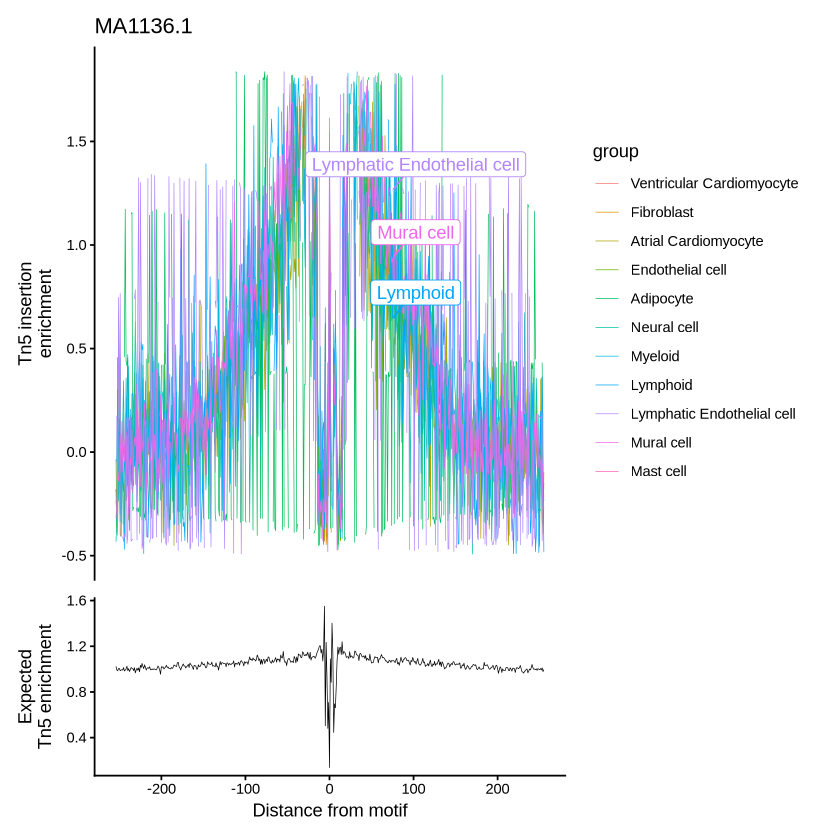

In [8]:
Signac::PlotFootprint(dissociated_obj, features = "MA1136.1")

Warning message:
"Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.
ℹ The deprecated feature was likely used in the Signac package.
  Please report the issue at <https://github.com/stuart-lab/signac/issues>."
Warning message:
"Removed 506 rows containing missing values or values outside the scale range
(`geom_line()`)."
Warning message:
"Removed 5654 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


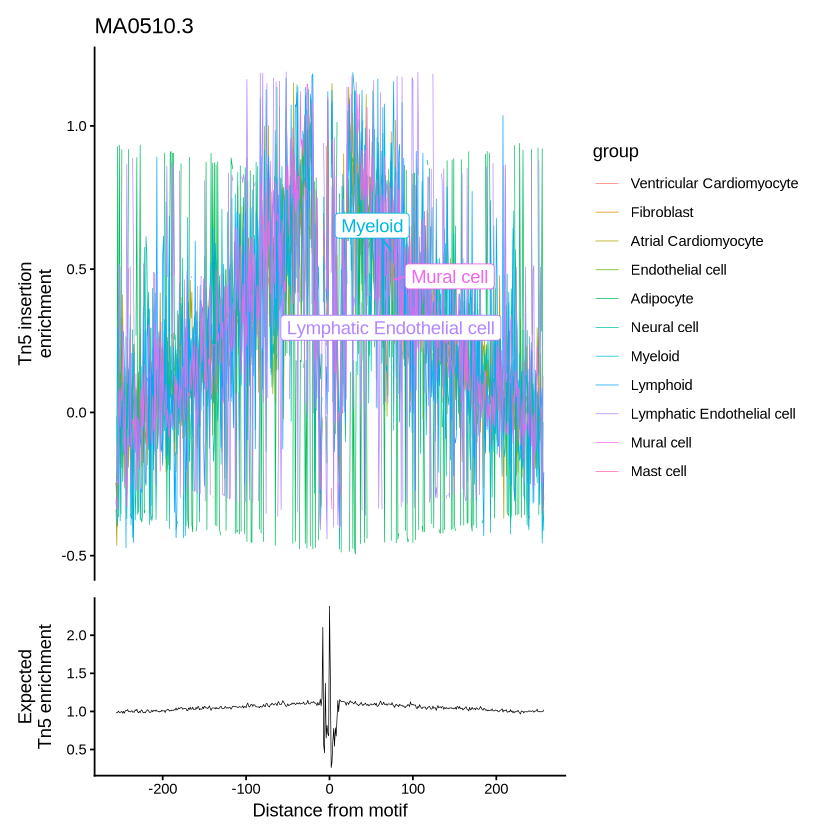

In [17]:
Signac::PlotFootprint(dissociated_obj, features = "MA0510.3")

In [9]:
dissociated_obj <- Signac::Footprint(
    object = dissociated_obj,
    motif.name = "SP1",
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE
  )

Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites



Warning message:
"Removed 5599 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


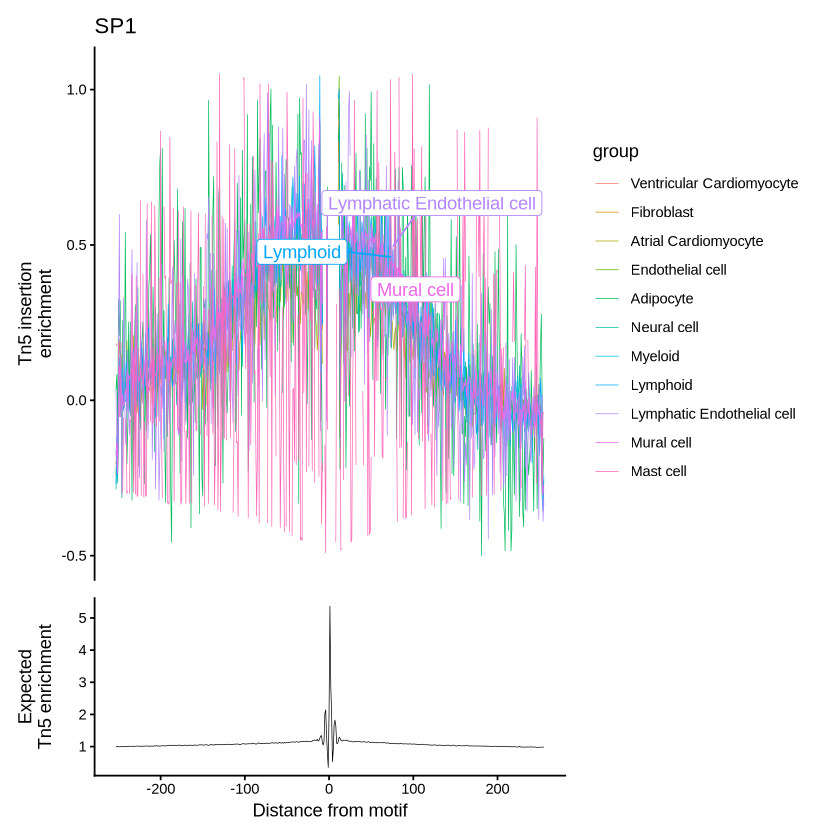

In [10]:
Signac::PlotFootprint(dissociated_obj, features = "SP1")

### compare to global object out

In [11]:
global_analysis <- readRDS("/nfs/home/students/m.back/swarm/backend/uploads/job_1775635064043_mopitas/plasmidpoop/global_motif_analysis.rds")

In [12]:
DefaultAssay(global_analysis) <- "peaks"
frag_obj <- CreateFragmentObject(
            path = "~/swarm/backend/data/cell_atlas/HCAHeartST11350194_HCAHeartST11445771_atac_fragments.tsv.gz",
            cells = colnames(global_analysis)   # restrict to cells in this object
        )
global_analysis[["peaks"]]@fragments <- list(frag_obj)

Computing hash



Computing observed Tn5 insertions per base

Computing base composition at motif sites

Computing expected Tn5 insertions per base

Finding + strand cut sites

Finding - strand cut sites

Warning message:
"Removed 5599 rows containing missing values or values outside the scale range
(`geom_label_repel()`)."


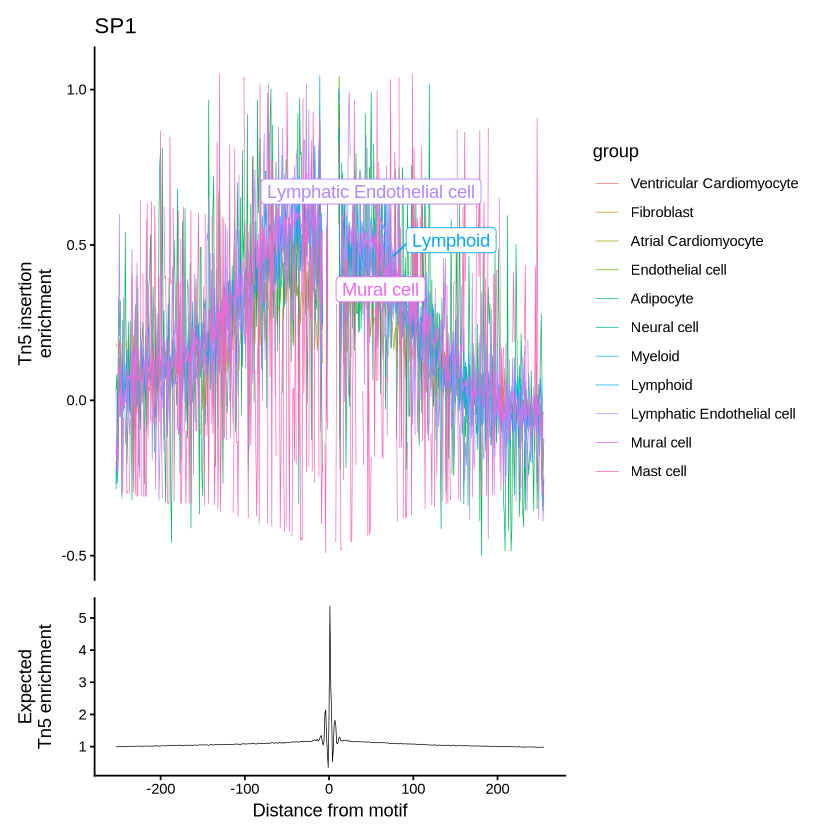

In [13]:
global_analysis <- Signac::Footprint(
    object = global_analysis,
    motif.name = "SP1",
    genome = BSgenome.Hsapiens.UCSC.hg38,
    in.peaks = TRUE
  )

Signac::PlotFootprint(global_analysis, features = "SP1")